# Online Review Sentiment Analysis (Flipkart / Twitter)
**Name:** Rabea Akter Shoily  |  **Student ID:** 905253001  |  United International University, School of Business and Economics

**Goal:** classify short online reviews as *positive*, *neutral* or *negative*, compare three text-classification models, and look at how sentiment varies over time, by source and by product.

**Workflow**
1. Load and explore the dataset (and check its quality)
2. Text preprocessing (tokenisation, stopword removal, TF-IDF)
3. Train/test splitting (a demo-style random split *and* a stricter split)
4. Model selection and implementation (3 models + a baseline + tuned versions)
5. Evaluation and model comparison
6. Visualising sentiment trends
7. Saving and re-loading the best pipeline
8. Result interpretation

> The data is synthetic (generated for teaching). That matters a lot for how the results must be read, see Sections 1 and 3.

In [1]:
import sys, warnings, joblib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, spearmanr

from sklearn.model_selection import train_test_split, StratifiedGroupKFold, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             classification_report, confusion_matrix)

# our own cleaning functions live in ../src/text_utils.py so the saved pipeline can be re-loaded later
sys.path.append('../src')
from text_utils import clean_text, clean_series, get_stopwords

warnings.filterwarnings('ignore')
SEED = 42                       # fixed seed -> reproducible results
np.random.seed(SEED)

DATA, OUT, MODELS = Path('../data'), Path('../outputs'), Path('../models')
OUT.mkdir(exist_ok=True); MODELS.mkdir(exist_ok=True)

CLASSES = ['negative', 'neutral', 'positive']
SENT_COLORS = {'negative': '#F2A03D', 'neutral': '#8FA3AD', 'positive': '#0E7C86'}
sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'DejaVu Serif'

def save_fig(name):
    plt.tight_layout()
    plt.savefig(OUT / name, dpi=200, bbox_inches='tight')
    plt.show()

print('Libraries ready.')

Libraries ready.


## 1. Load and explore the dataset

In [2]:
df = pd.read_csv(DATA / 'online_reviews_sentiment.csv', parse_dates=['date'])
print('Shape:', df.shape, '| missing values:', int(df.isna().sum().sum()))
print('Date range:', df['date'].min().date(), 'to', df['date'].max().date())
df.head()

Shape: (1000, 7) | missing values: 0
Date range: 2025-01-01 to 2025-12-31


,review_id,review_text,product,sentiment,source,date,rating
0,1,"Excellent build quality on this Yoga Mat, usin...",Yoga Mat,positive,Flipkart,2025-11-25,3
1,2,"Best Power Bank I have ever bought, highly rec...",Power Bank,positive,Flipkart,2025-07-14,3
2,3,I'm impressed by how well this Wireless Earbud...,Wireless Earbuds,positive,Flipkart,2025-04-12,5
3,4,"Best Bluetooth Speaker I have ever bought, hig...",Bluetooth Speaker,positive,Flipkart,2025-05-01,3
4,5,"The Power Bank exceeded my expectations, fast ...",Power Bank,positive,Flipkart,2025-02-14,3


In [3]:
print(df['sentiment'].value_counts(), '\n')
print(df['source'].value_counts(), '\n')
print(f"Products: {df['product'].nunique()}")

sentiment
positive    400
negative    340
neutral     260
Name: count, dtype: int64 

source
Flipkart    600
Twitter     400
Name: count, dtype: int64 

Products: 15


### Data-quality checks
Two things are worth checking before modelling: (a) are the review texts repeated, and (b) does the `rating` column agree with the sentiment label?

In [4]:
# (a) repeated texts. Reviews seem to be filled in from sentence templates, so mask the product name and @mention
products = sorted(df['product'].unique(), key=len, reverse=True)
def make_template(text):
    text = text.replace('@Flipkart', '@USER')
    for p in products:
        text = text.replace(p, 'PRODUCT')
    return text

df['template'] = df['review_text'].apply(make_template)
print('Rows:                   ', len(df))
print('Unique review texts:    ', df['review_text'].nunique())
print('Unique sentence templates:', df['template'].nunique())
print('Templates per class:\n', df.groupby('sentiment')['template'].nunique().to_string())
print('Templates that appear under more than one label:',
      int((df.groupby('template')['sentiment'].nunique() > 1).sum()))

Rows:                    1000
Unique review texts:     497
Unique sentence templates: 42
Templates per class:
 sentiment
negative    14
neutral     14
positive    14
Templates that appear under more than one label: 0


Spearman correlation between rating and sentiment: -0.005 (p = 0.87)


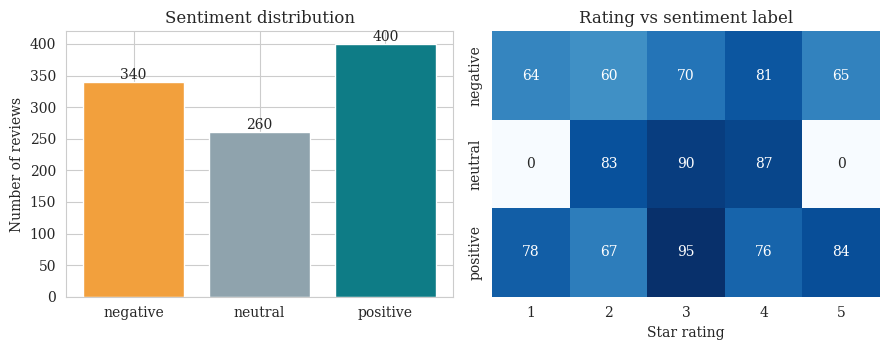

In [5]:
# (b) rating vs sentiment
rho, p = spearmanr(df['rating'], df['sentiment'].map({'negative': 0, 'neutral': 1, 'positive': 2}))
print(f'Spearman correlation between rating and sentiment: {rho:.3f} (p = {p:.2f})')

fig, ax = plt.subplots(1, 2, figsize=(9, 3.6))
counts = df['sentiment'].value_counts().reindex(CLASSES)
bars = ax[0].bar(counts.index, counts.values, color=[SENT_COLORS[c] for c in counts.index])
ax[0].bar_label(bars)
ax[0].set_title('Sentiment distribution'); ax[0].set_ylabel('Number of reviews')
sns.heatmap(pd.crosstab(df['sentiment'], df['rating']).reindex(CLASSES), annot=True, fmt='d',
            cmap='Blues', cbar=False, ax=ax[1])
ax[1].set_title('Rating vs sentiment label'); ax[1].set_xlabel('Star rating'); ax[1].set_ylabel('')
save_fig('01_data_overview.png')

**What this tells us**
- The classes are moderately balanced (positive 40%, negative 34%, neutral 26%).
- The 1,000 rows contain only **42 distinct sentence templates** (14 per class); the product name is the only part that changes. Each template always has the same label.
- The star `rating` is almost unrelated to the sentiment label (e.g. negative reviews have 5-star ratings), so it is **not used as a feature**. Only the review text is.

## 2. Text preprocessing

Three standard steps: **tokenisation**, **stopword removal** and **TF-IDF**.

One choice differs from the class demo: NLTK's stopword list contains *no, nor, not*. Removing them changes "not happy" into "happy", the opposite meaning, so we **keep the negation words**. Section 4 tests whether this matters.

In [6]:
removed_by_demo_only = sorted(get_stopwords(False) - get_stopwords(True))
print('Negation words kept (the demo would remove them):', removed_by_demo_only)

df['clean_demo'] = df['review_text'].apply(lambda t: clean_text(t, keep_negations=False))   # as in class demo
df['clean_neg']  = df['review_text'].apply(lambda t: clean_text(t, keep_negations=True))    # negations kept
df[['review_text', 'clean_demo', 'clean_neg']].iloc[[4, 25, 40, 90, 150, 200]]

Negation words kept (the demo would remove them): ['don', 'no', 'nor', 'not', 't']


,review_text,clean_demo,clean_neg
4,"The Power Bank exceeded my expectations, fast ...",power bank exceeded expectations fast delivery,power bank exceeded expectations fast delivery
25,"Can't stop using my Office Chair, best purchas...",cant stop using office chair best purchase year,cant stop using office chair best purchase year
40,I'm impressed by how well this Air Fryer perfo...,im impressed well air fryer performs buy,im impressed well air fryer performs buy
90,"Running Shoes is amazing, exceeded all expecta...",running shoes amazing exceeded expectations re...,running shoes amazing exceeded expectations re...
150,Neutral experience overall with this Laptop Ba...,neutral experience overall laptop backpack mee...,neutral experience overall laptop backpack mee...
200,Shoutout to great customer service for my Cott...,shoutout great customer service cotton tshirt ...,shoutout great customer service cotton tshirt ...


## 3. Train/test split

The class demo uses a random 80/20 split of the rows. Because every template appears about 24 times in the data, a random split puts **the same sentence in both train and test**, so the model is tested on sentences it has already memorised.

We therefore use two splits and compare them:
- **Random split (demo style):** stratified 80/20 on rows.
- **Template hold-out split (strict):** whole templates are held out, so the test set contains sentence patterns the model has never seen. This is much closer to real use, where new reviews are worded differently. It is done with `StratifiedGroupKFold`, grouping rows by `template`.

In [7]:
idx = np.arange(len(df))

# (a) demo-style random split
rand_tr, rand_te = train_test_split(idx, test_size=0.2, random_state=SEED, stratify=df['sentiment'])

# (b) strict split: whole templates go either to train or to test (about 20% of rows in test)
sgk = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
strict_tr, strict_te = next(sgk.split(df, df['sentiment'], groups=df['template']))

for name, tr, te in [('Random split', rand_tr, rand_te), ('Template hold-out', strict_tr, strict_te)]:
    seen_text = df.iloc[te]['review_text'].isin(set(df.iloc[tr]['review_text'])).mean()
    seen_tmpl = df.iloc[te]['template'].isin(set(df.iloc[tr]['template'])).mean()
    print(f'{name:18s} train={len(tr)}, test={len(te)} | test rows whose exact text is in train: {seen_text:.0%}'
          f' | whose template is in train: {seen_tmpl:.0%}')
print()
print('Test class mix (strict split):', df.iloc[strict_te]['sentiment'].value_counts().to_dict())
print('Test templates (strict split):', df.iloc[strict_te]['template'].nunique())

Random split       train=800, test=200 | test rows whose exact text is in train: 76% | whose template is in train: 100%
Template hold-out  train=804, test=196 | test rows whose exact text is in train: 0% | whose template is in train: 0%

Test class mix (strict split): {'positive': 74, 'negative': 68, 'neutral': 54}
Test templates (strict split): 8


## 4. Model selection and implementation

Models (same three as the demo, plus a baseline):
- **Majority baseline**: always predicts the most common class (the score to beat).
- **Logistic Regression**: fast, strong linear model.
- **Multinomial Naive Bayes**: classic, very fast text model.
- **Linear SVM**: often the strongest linear model on TF-IDF features.

Because the strict hold-out set has only about 8 templates, one split gives a noisy score. So every model is also scored with **repeated grouped cross-validation** (3 repeats x 5 folds, templates never shared between train and test).

In [8]:
def fit_model(model, X, y, groups):
    # GridSearchCV needs the template groups so its inner folds also keep templates apart
    if isinstance(model, GridSearchCV):
        model.fit(X, y, groups=groups)
    else:
        model.fit(X, y)
    return model

def grouped_cv(make_model, X, y, groups, n_repeats=3, n_splits=5):
    # repeated stratified, template-grouped K-fold cross-validation
    rows = []
    for rep in range(n_repeats):
        cv = StratifiedGroupKFold(n_splits, shuffle=True, random_state=SEED + rep)
        for tr, te in cv.split(X, y, groups):
            m = fit_model(make_model(), X.iloc[tr], y.iloc[tr], groups.iloc[tr])
            pred = m.predict(X.iloc[te])
            p, r, f, _ = precision_recall_fscore_support(y.iloc[te], pred, average='weighted', zero_division=0)
            rows.append({'acc': accuracy_score(y.iloc[te], pred), 'f1': f})
    return pd.DataFrame(rows)

y, groups = df['sentiment'], df['template']

### 4.1 Design experiment: negation handling and n-grams
Same three models, two text-cleaning options (demo stopwords vs negations kept) and two TF-IDF settings (unigrams vs unigrams+bigrams). The score is the cross-validated weighted F1 on unseen templates.

In [9]:
exp_models = {'Logistic Regression': lambda ng: Pipeline([('tfidf', TfidfVectorizer(max_features=3000, ngram_range=ng)), ('clf', LogisticRegression(max_iter=1000))]),
              'Multinomial NB':      lambda ng: Pipeline([('tfidf', TfidfVectorizer(max_features=3000, ngram_range=ng)), ('clf', MultinomialNB())]),
              'Linear SVM':          lambda ng: Pipeline([('tfidf', TfidfVectorizer(max_features=3000, ngram_range=ng)), ('clf', LinearSVC())])}
rows = []
for col, cfg_name in [('clean_demo', 'Demo stopwords'), ('clean_neg', 'Negations kept')]:
    for ng, ng_name in [((1, 1), 'unigrams'), ((1, 2), 'uni+bigrams')]:
        row = {'Cleaning': cfg_name, 'TF-IDF': ng_name}
        for mname, mk in exp_models.items():
            row[mname] = grouped_cv(lambda: mk(ng), df[col], y, groups)['f1'].mean()
        row['Average'] = np.mean([row[m] for m in exp_models])
        rows.append(row)
exp_df = pd.DataFrame(rows)
exp_df.to_csv(OUT / '02_design_experiment.csv', index=False)
exp_df.round(3)

,Cleaning,TF-IDF,Logistic Regression,Multinomial NB,Linear SVM,Average
0,Demo stopwords,unigrams,0.700,0.700,0.771,0.724
1,Demo stopwords,uni+bigrams,0.664,0.683,0.711,0.686
2,Negations kept,unigrams,0.748,0.730,0.804,0.761
3,Negations kept,uni+bigrams,0.721,0.709,0.775,0.735


In [10]:
# choose the configuration with the best average cross-validated F1 and use it from here on
best_cfg = exp_df.sort_values('Average', ascending=False).iloc[0]
KEEP_NEG = best_cfg['Cleaning'] == 'Negations kept'
NGRAM = (1, 1) if best_cfg['TF-IDF'] == 'unigrams' else (1, 2)
df['clean_text'] = df['clean_neg'] if KEEP_NEG else df['clean_demo']
print(f"Chosen: cleaning = {best_cfg['Cleaning']}, TF-IDF = {best_cfg['TF-IDF']}, ngram_range = {NGRAM}")

tfidf_demo = TfidfVectorizer(max_features=3000, ngram_range=NGRAM).fit(df['clean_text'])
print('Vocabulary size:', len(tfidf_demo.vocabulary_), '| sample terms:', list(tfidf_demo.vocabulary_)[:12])

Chosen: cleaning = Negations kept, TF-IDF = unigrams, ngram_range = (1, 1)
Vocabulary size: 185 | sample terms: ['excellent', 'build', 'quality', 'yoga', 'mat', 'using', 'daily', 'without', 'issues', 'best', 'power', 'bank']


### 4.2 The models
We train the baseline and the three models with default settings, plus a **tuned** version of each (regularisation strength chosen by grid search with template-grouped inner folds, so tuning never sees the test templates).

In [11]:
def build(clf):
    return Pipeline([('tfidf', TfidfVectorizer(max_features=3000, ngram_range=NGRAM)), ('clf', clf)])

def tuned(clf, grid):
    inner = StratifiedGroupKFold(3, shuffle=True, random_state=SEED)
    return GridSearchCV(build(clf), grid, cv=inner, scoring='f1_weighted')

MODEL_FACTORIES = {
    'Majority baseline':            lambda: build(DummyClassifier(strategy='most_frequent')),
    'Logistic Regression':          lambda: build(LogisticRegression(max_iter=1000)),
    'Multinomial Naive Bayes':      lambda: build(MultinomialNB()),
    'Linear SVM':                   lambda: build(LinearSVC()),
    'Logistic Regression (tuned)':  lambda: tuned(LogisticRegression(max_iter=1000), {'clf__C': [0.1, 1, 10, 100]}),
    'Naive Bayes (tuned)':          lambda: tuned(MultinomialNB(), {'clf__alpha': [0.01, 0.1, 0.5, 1.0]}),
    'Linear SVM (tuned)':           lambda: tuned(LinearSVC(), {'clf__C': [0.1, 0.5, 1, 5]}),
}
X = df['clean_text']
print('Models defined:', list(MODEL_FACTORIES))

Models defined: ['Majority baseline', 'Logistic Regression', 'Multinomial Naive Bayes', 'Linear SVM', 'Logistic Regression (tuned)', 'Naive Bayes (tuned)', 'Linear SVM (tuned)']


## 5. Evaluation and model comparison

In [12]:
results = []
for name, make in MODEL_FACTORIES.items():
    # strict hold-out (unseen templates)
    m = fit_model(make(), X.iloc[strict_tr], y.iloc[strict_tr], groups.iloc[strict_tr])
    pred = m.predict(X.iloc[strict_te])
    prec, rec, f1, _ = precision_recall_fscore_support(y.iloc[strict_te], pred, average='weighted', zero_division=0)
    # demo-style random split (for comparison only)
    mr = fit_model(make(), X.iloc[rand_tr], y.iloc[rand_tr], groups.iloc[rand_tr])
    f1_rand = precision_recall_fscore_support(y.iloc[rand_te], mr.predict(X.iloc[rand_te]), average='weighted', zero_division=0)[2]
    # repeated grouped cross-validation
    cv = grouped_cv(make, X, y, groups)
    results.append({'Model': name, 'Accuracy': accuracy_score(y.iloc[strict_te], pred), 'Precision': prec,
                    'Recall': rec, 'F1-score': f1, 'CV F1 (mean)': cv['f1'].mean(), 'CV F1 (std)': cv['f1'].std(),
                    'Random-split F1': f1_rand,
                    'best params': getattr(m, 'best_params_', '')})

results_df = pd.DataFrame(results).sort_values('CV F1 (mean)', ascending=False).reset_index(drop=True)
results_df.drop(columns='best params').round(3).to_csv(OUT / '03_model_comparison.csv', index=False)
results_df.drop(columns='best params').round(3)

,Model,Accuracy,Precision,Recall,F1-score,CV F1 (mean),CV F1 (std),Random-split F1
0,Linear SVM,0.806,0.872,0.806,0.807,0.804,0.090,1.000
1,Linear SVM (tuned),0.801,0.870,0.801,0.802,0.800,0.104,1.000
2,Logistic Regression (tuned),0.699,0.741,0.699,0.706,0.770,0.088,1.000
3,Logistic Regression,0.755,0.851,0.755,0.749,0.748,0.058,1.000
4,Multinomial Naive Bayes,0.745,0.826,0.745,0.731,0.730,0.059,1.000
5,Naive Bayes (tuned),0.684,0.712,0.684,0.678,0.723,0.102,1.000
6,Majority baseline,0.378,0.143,0.378,0.207,0.229,0.013,0.229


In [13]:
print('Hyper-parameters picked on the hold-out training templates:')
print(results_df.loc[results_df['best params'] != '', ['Model', 'best params']].to_string(index=False))

Hyper-parameters picked on the hold-out training templates:
                      Model         best params
         Linear SVM (tuned)     {'clf__C': 0.5}
Logistic Regression (tuned)     {'clf__C': 100}
        Naive Bayes (tuned) {'clf__alpha': 0.1}


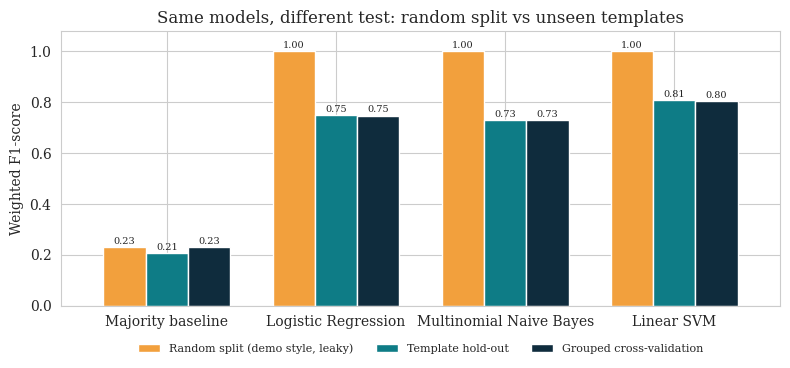

In [14]:
# the demo-split score vs the strict scores, for the untuned models
base = results_df[~results_df['Model'].str.contains('tuned')].set_index('Model').loc[
    ['Majority baseline', 'Logistic Regression', 'Multinomial Naive Bayes', 'Linear SVM']]
fig, ax = plt.subplots(figsize=(8, 3.8))
base[['Random-split F1', 'F1-score', 'CV F1 (mean)']].plot.bar(
    ax=ax, color=['#F2A03D', '#0E7C86', '#0F2C3D'], width=0.75)
ax.legend(['Random split (demo style, leaky)', 'Template hold-out', 'Grouped cross-validation'], fontsize=8,
          loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3, frameon=False)
ax.set_ylabel('Weighted F1-score'); ax.set_ylim(0, 1.08); ax.set_xlabel('')
plt.xticks(rotation=0); ax.set_title('Same models, different test: random split vs unseen templates')
for c in ax.containers: ax.bar_label(c, fmt='%.2f', fontsize=7, padding=1)
save_fig('04_model_comparison.png')

### Best model: confusion matrix and error analysis
The best model is chosen by **cross-validated F1** (not by the single hold-out score, to avoid picking the model that got lucky on 8 templates). To look at errors on all 1,000 reviews, we use out-of-fold predictions: every review is predicted by a model that never saw its template.

Best model by CV F1: Linear SVM
              precision    recall  f1-score   support

    negative       0.82      0.86      0.84       340
     neutral       0.75      0.61      0.67       260
    positive       0.83      0.89      0.86       400

    accuracy                           0.81      1000
   macro avg       0.80      0.79      0.79      1000
weighted avg       0.80      0.81      0.80      1000



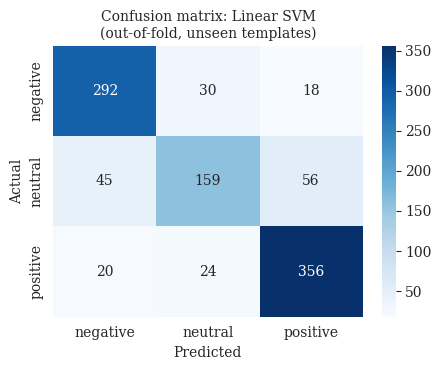

In [15]:
best_name = results_df.iloc[0]['Model']
print('Best model by CV F1:', best_name)

oof = np.empty(len(df), dtype=object)
for tr, te in StratifiedGroupKFold(5, shuffle=True, random_state=SEED).split(X, y, groups):
    m = fit_model(MODEL_FACTORIES[best_name](), X.iloc[tr], y.iloc[tr], groups.iloc[tr])
    oof[te] = m.predict(X.iloc[te])
df['oof_pred'] = oof

print(classification_report(y, oof, zero_division=0))
cm = confusion_matrix(y, oof, labels=CLASSES)
plt.figure(figsize=(4.6, 3.8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES)
plt.title(f'Confusion matrix: {best_name}\n(out-of-fold, unseen templates)', fontsize=10)
plt.xlabel('Predicted'); plt.ylabel('Actual')
save_fig('05_confusion_matrix.png')

In [16]:
# which sentence templates does the model get wrong?
err = (df.assign(wrong=lambda d: d['sentiment'] != d['oof_pred'])
         .groupby('template')
         .agg(label=('sentiment', 'first'), n=('wrong', 'size'), error_rate=('wrong', 'mean'),
              mostly_predicted=('oof_pred', lambda s: s.value_counts().index[0]))
         .sort_values('error_rate', ascending=False))
err.head(10).round(2).to_csv(OUT / '06_hardest_templates.csv')
pd.set_option('display.max_colwidth', 80)
err.head(10).round(2)

,label,n,error_rate,mostly_predicted
template,,,,
Absolutely love this PRODUCT! Works perfectly and arrived early.,positive,24,1.00,neutral
"Got the PRODUCT yesterday, still testing it out.",neutral,18,1.00,positive
Late delivery and the PRODUCT was defective on arrival.,negative,18,1.00,positive
"The PRODUCT works fine, packaging could be improved.",neutral,15,1.00,positive
"Thinking about buying a PRODUCT, any recommendations?",neutral,24,1.00,negative
"This PRODUCT is a total game changer, five stars!",positive,20,1.00,negative
"It's a decent PRODUCT for the price, no major complaints.",neutral,16,1.00,positive
"Neutral experience overall with this PRODUCT, meets basic needs.",neutral,17,1.00,negative
"@USER my PRODUCT arrived broken, this is unacceptable",negative,35,0.86,neutral


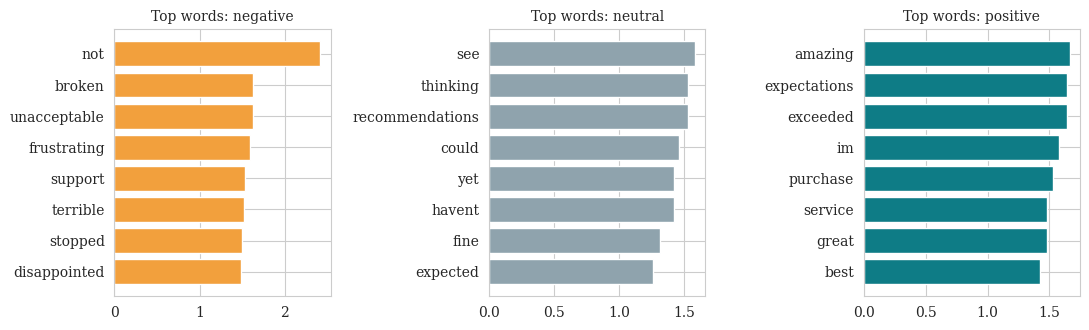

In [17]:
# most influential words per class (Logistic Regression fitted on all data, for interpretation only)
lr_vec = TfidfVectorizer(max_features=3000, ngram_range=NGRAM)
lr = LogisticRegression(max_iter=1000).fit(lr_vec.fit_transform(X), y)
terms = np.array(lr_vec.get_feature_names_out())
fig, axes = plt.subplots(1, 3, figsize=(11, 3.4))
for ax, cls_i, cls in zip(axes, range(3), lr.classes_):
    top = np.argsort(lr.coef_[cls_i])[-8:]
    ax.barh(terms[top], lr.coef_[cls_i][top], color=SENT_COLORS[cls])
    ax.set_title(f'Top words: {cls}', fontsize=10)
save_fig('07_top_words.png')

## 6. Visualising sentiment trends

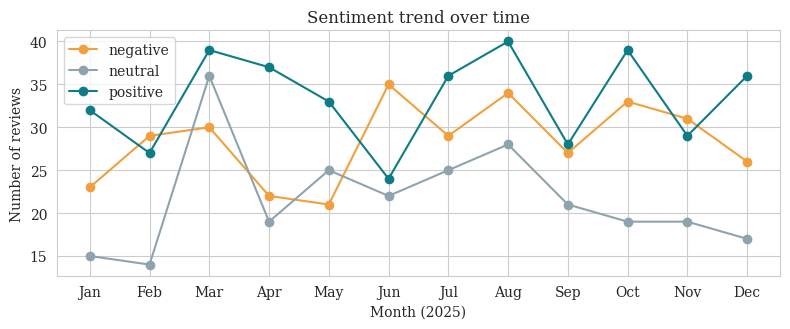

Month x sentiment chi-square p-value: 0.598
Positive share by month (%): [46, 39, 37, 47, 42, 30, 40, 39, 37, 43, 37, 46]


In [18]:
monthly = (df.set_index('date').groupby([pd.Grouper(freq='ME'), 'sentiment']).size()
             .unstack(fill_value=0)[CLASSES])
fig, ax = plt.subplots(figsize=(8, 3.4))
for c in CLASSES:
    ax.plot(monthly.index.strftime('%b'), monthly[c], marker='o', label=c, color=SENT_COLORS[c])
ax.set_ylabel('Number of reviews'); ax.set_xlabel('Month (2025)'); ax.legend()
ax.set_title('Sentiment trend over time')
save_fig('08_sentiment_trend.png')

print('Month x sentiment chi-square p-value:', round(chi2_contingency(monthly)[1], 3))
print('Positive share by month (%):', (monthly['positive'] / monthly.sum(axis=1) * 100).round(0).astype(int).tolist())

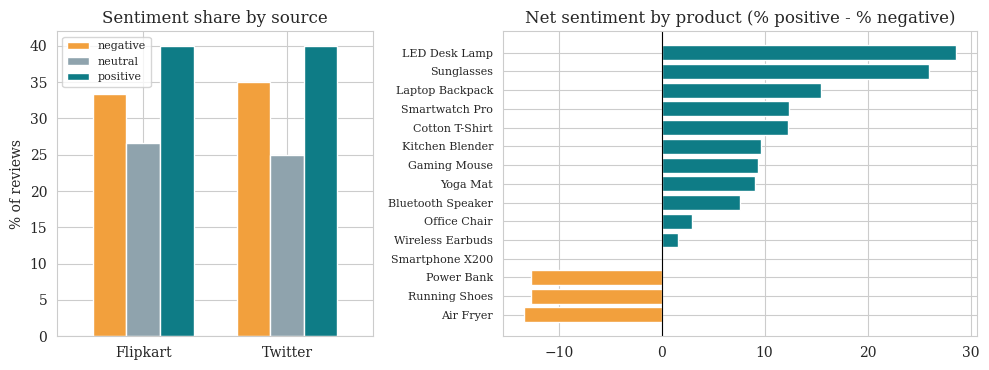

Source x sentiment chi-square p-value: 0.798
Product x sentiment chi-square p-value: 0.397
sentiment  negative  neutral  positive
source                                
Flipkart       33.3     26.7      40.0
Twitter        35.0     25.0      40.0
sentiment        negative  neutral  positive  net
product                                          
Air Fryer              43       28        29  -13
Running Shoes          42       29        29  -13
Power Bank             44       25        31  -13
Laptop Backpack        30       25        45   15
Sunglasses             22       30        48   26
LED Desk Lamp          21       29        50   29


In [19]:
src = pd.crosstab(df['source'], df['sentiment'], normalize='index')[CLASSES] * 100
prod = pd.crosstab(df['product'], df['sentiment'], normalize='index')[CLASSES] * 100
prod['net'] = prod['positive'] - prod['negative']
prod = prod.sort_values('net')

fig, ax = plt.subplots(1, 2, figsize=(10, 3.8), gridspec_kw={'width_ratios': [1, 1.5]})
src.plot.bar(ax=ax[0], color=[SENT_COLORS[c] for c in CLASSES], width=0.7)
ax[0].set_title('Sentiment share by source'); ax[0].set_ylabel('% of reviews'); ax[0].set_xlabel('')
ax[0].tick_params(axis='x', rotation=0); ax[0].legend(fontsize=8)
ax[1].barh(prod.index, prod['net'], color=np.where(prod['net'] >= 0, '#0E7C86', '#F2A03D'))
ax[1].axvline(0, color='k', lw=0.8)
ax[1].set_title('Net sentiment by product (% positive - % negative)'); ax[1].tick_params(axis='y', labelsize=8)
save_fig('09_source_and_product.png')

print('Source x sentiment chi-square p-value:', round(chi2_contingency(pd.crosstab(df['source'], df['sentiment']))[1], 3))
print('Product x sentiment chi-square p-value:', round(chi2_contingency(pd.crosstab(df['product'], df['sentiment']))[1], 3))
print(src.round(1))
print(prod[['negative', 'neutral', 'positive', 'net']].round(0).astype(int).iloc[[0, 1, 2, -3, -2, -1]])

## 7. Saving and re-loading the best pipeline
The full pipeline (cleaning + TF-IDF + model) is saved as **one file**, so raw review text goes in and a label comes out. The best configuration is refitted on all 1,000 reviews before saving.

In [20]:
final = fit_model(MODEL_FACTORIES[best_name](), X, y, groups)           # refit on all data
deploy = Pipeline([('clean', FunctionTransformer(clean_series, kw_args={'keep_negations': KEEP_NEG})),
                   ('model', final)])
deploy.named_steps['clean'].fit(df['review_text'])                       # mark the cleaning step as fitted
joblib.dump(deploy, MODELS / 'sentiment_pipeline.joblib')

loaded = joblib.load(MODELS / 'sentiment_pipeline.joblib')               # re-load from disk
assert (loaded.predict(df['review_text'].iloc[:50]) == deploy.predict(df['review_text'].iloc[:50])).all()
print('Saved and re-loaded OK. Re-loaded predictions match the original.')

Saved and re-loaded OK. Re-loaded predictions match the original.


In [21]:
new_reviews = [
    'Best Camera I have ever bought, highly recommend to everyone.',     # known wording, new product
    'Terrible experience, the Monitor does not match the description.',  # known wording, new product
    'The Router is okay, does the job but nothing special.',             # known wording, new product
    'Absolutely love this blender, works perfectly every day!',          # NEW wording
    'Not good at all, it stopped working after two days.',               # NEW wording with a negation
    'It is fine I guess, nothing special.',                              # NEW wording, neutral
    'Thinking of getting a new phone, any suggestions?',                 # NEW wording, neutral
]
demo_out = pd.DataFrame({'review': new_reviews, 'predicted sentiment': loaded.predict(new_reviews)})
demo_out.to_csv(OUT / '10_new_review_predictions.csv', index=False)
demo_out

,review,predicted sentiment
0,"Best Camera I have ever bought, highly recommend to everyone.",positive
1,"Terrible experience, the Monitor does not match the description.",negative
2,"The Router is okay, does the job but nothing special.",neutral
3,"Absolutely love this blender, works perfectly every day!",positive
4,"Not good at all, it stopped working after two days.",negative
5,"It is fine I guess, nothing special.",neutral
6,"Thinking of getting a new phone, any suggestions?",neutral


## 8. Result interpretation

**1. Which model performed best, and why?**
The **Linear SVM** was best: F1 = 0.807 on the unseen-template hold-out and 0.804 in cross-validation (std about 0.09), against 0.749 / 0.748 for Logistic Regression, 0.731 / 0.730 for Naive Bayes and 0.21 / 0.23 for the majority baseline. It also came first in all four cleaning/n-gram settings of Section 4.1, so the ranking is consistent, although the gap to Logistic Regression is smaller than the fold-to-fold spread and should be read as a likely advantage, not a certainty. A plausible reason is that TF-IDF features are sparse, high-dimensional and close to linearly separable, which suits the SVM's margin-based fit. **Tuning did not help consistently:** the tuned SVM (0.800) and tuned Naive Bayes (0.723) were no better than their defaults, and tuned Logistic Regression gained in cross-validation (0.770 vs 0.748) but lost on the hold-out (0.706 vs 0.749). With so few distinct templates, tuning mostly adds noise, so the default Linear SVM is the model to use.

**2. Which sentiment class is confused most, and why?**
**Neutral** is the weakest class (recall 0.61): 45 neutral reviews were labelled negative and 56 positive, while positive and negative recall are 0.89 and 0.86. Neutral templates mix mild praise ("works fine", "decent"), mild complaints ("packaging could be improved", "late delivery") and sentences with no opinion words at all ("Comparing a few options before I decide"), so they overlap with both other classes. The error analysis also shows that errors come **template by template**: 8 of the 42 templates were wrong for every review (error rate 100%), and each of those has wording the model could not match to the other templates it had seen. The model has learned a small dictionary of phrases more than a general idea of sentiment. It does pick up sensible cues, e.g. *not*, *broken*, *unacceptable* for negative and *amazing*, *exceeded*, *best* for positive.

**3. Why the random split is misleading.**
With the demo's random split every model scored F1 = 1.00, and 76% of test reviews had an exact copy in the training data (100% had the same template). Perfect scores like that cannot separate good models from bad ones. When whole templates are held out, scores fall to 0.73-0.81, the models can finally be told apart, and this is the more honest estimate of how the model would behave on new wording.

**4. Did the preprocessing choices matter?**
Yes. Keeping negation words raised the average cross-validated F1 from 0.724 to 0.761 (unigrams), because *not* is the strongest single negative cue. Unigrams beat unigrams+bigrams (0.761 vs 0.735): with only 42 templates, bigrams are too specific and overfit.

**5. Sentiment trends.**
Opinion is spread fairly evenly through 2025: positive reviews are 30-47% of reviews each month (neutral peaks at 36 reviews in March), and the month-to-month changes are within chance (chi-square p = 0.60). **Flipkart and Twitter look almost identical** (positive 40% on both; negative 33% vs 35%; neutral 27% vs 25%; p = 0.80). Tweets have different wording (mentions, hashtags, questions) but not a different sentiment mix. By product, Air Fryer, Running Shoes and Power Bank are the most negative (net -13 points) and LED Desk Lamp and Sunglasses the most positive (+29, +26), but with 15 products and about 66 reviews each this is not statistically significant (p = 0.40). Because the data is synthetic with random dates, none of these patterns should be treated as real market findings.

**6. Limitations and next steps.**
(a) The data is synthetic and built from only 42 sentence templates, so results will not carry over to real reviews. *Next step:* repeat on real Flipkart/Twitter reviews. (b) The strict hold-out has only 8 templates, so one split is noisy; repeated grouped cross-validation is the better guide. (c) The star rating does not match the sentiment label, so it was ignored. *Next step:* check how labels were produced, or use rating only on real data. (d) Sarcasm, emoji, spelling mistakes and mixed languages are absent. *Next step:* try a pre-trained transformer model (e.g. a fine-tuned BERT), which handles new wording much better than TF-IDF.